<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week3_Day2_Exercises_XP_Gold.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Exercise 1 : Eigenvalues, Eigenvectors & Normalisation
# ============================================================

import numpy as np

# Matrice aléatoire 5x5
matrix = np.random.rand(5, 5)
print("Matrice originale :")
print(matrix.round(3))

# ── 1) Valeurs propres et vecteurs propres ──────────────────
# np.linalg.eig retourne :
#   - eigenvalues  : tableau 1D des valeurs propres (λ)
#   - eigenvectors : matrice 2D où chaque COLONNE est un vecteur propre
eigenvalues, eigenvectors = np.linalg.eig(matrix)

print("\nValeurs propres (eigenvalues) :")
print(eigenvalues.round(3))

print("\nVecteurs propres (eigenvectors) :")
print(eigenvectors.round(3))

# ── 2) Normalisation Min-Max ────────────────────────────────
# Ramène toutes les valeurs entre 0 et 1
# Formule : (x - min) / (max - min)
min_val = matrix.min()
max_val = matrix.max()
matrix_normalized = (matrix - min_val) / (max_val - min_val)

print("\nMatrice normalisée (Min-Max → [0, 1]) :")
print(matrix_normalized.round(3))

# Vérification
print(f"\n→ Min après normalisation : {matrix_normalized.min():.2f}")
print(f"→ Max après normalisation : {matrix_normalized.max():.2f}")

# Bonus : normalisation Z-score (standardisation)
matrix_zscore = (matrix - matrix.mean()) / matrix.std()
print(f"\nBonus — Z-score : moyenne = {matrix_zscore.mean():.2f}, std = {matrix_zscore.std():.2f}")

Matrice originale :
[[0.253 0.07  0.04  0.661 0.062]
 [0.381 0.425 0.931 0.955 0.558]
 [0.475 0.545 0.221 0.892 0.071]
 [0.959 0.258 0.609 0.89  0.642]
 [0.925 0.832 0.449 0.867 0.406]]

Valeurs propres (eigenvalues) :
[ 2.629+0.j   -0.443+0.11j -0.443-0.11j  0.374+0.j    0.078+0.j  ]

Vecteurs propres (eigenvectors) :
[[-0.176+0.j     0.487+0.154j  0.487-0.154j  0.456+0.j    -0.32 +0.j   ]
 [-0.538+0.j    -0.215+0.13j  -0.215-0.13j  -0.68 +0.j     0.281+0.j   ]
 [-0.359+0.j     0.566+0.j     0.566-0.j    -0.042+0.j    -0.453+0.j   ]
 [-0.504+0.j    -0.547-0.073j -0.547+0.073j  0.208+0.j     0.009+0.j   ]
 [-0.544+0.j    -0.032-0.224j -0.032+0.224j -0.534+0.j     0.783+0.j   ]]

Matrice normalisée (Min-Max → [0, 1]) :
[[0.232 0.033 0.    0.676 0.024]
 [0.371 0.419 0.969 0.996 0.564]
 [0.473 0.549 0.197 0.926 0.033]
 [1.    0.237 0.619 0.924 0.655]
 [0.962 0.861 0.445 0.899 0.398]]

→ Min après normalisation : 0.00
→ Max après normalisation : 1.00

Bonus — Z-score : moyenne = 0.00, std 

Moyenne   : 0.0037
Médiane   : 0.0043
Écart-type: 0.9956
Skewness  : 0.0107
Kurtosis  : 0.0064


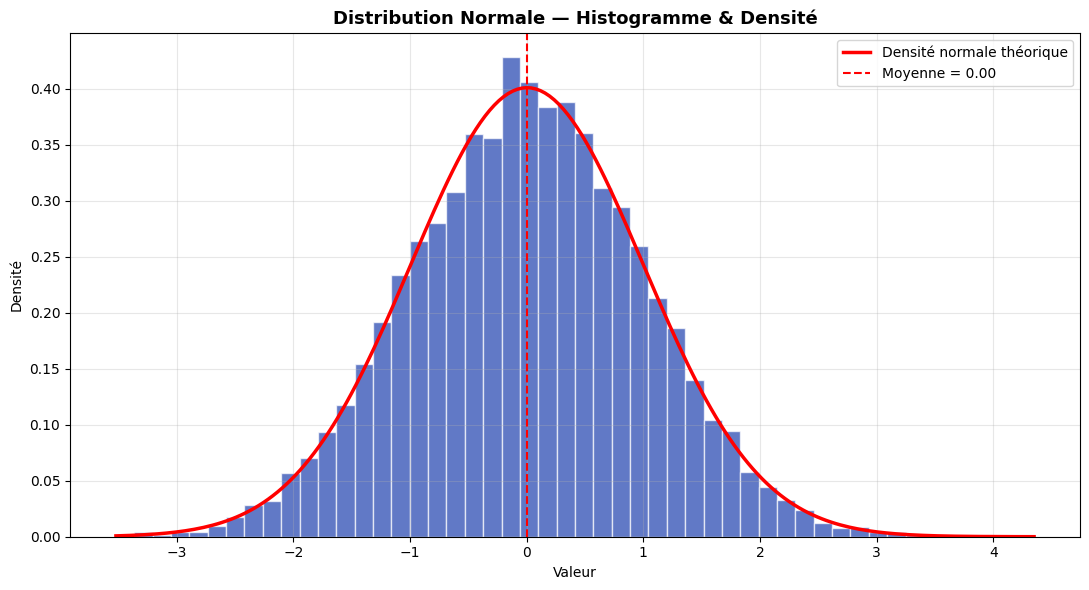


── Interprétation ──
• Skewness ≈ 0  → distribution symétrique
• Kurtosis ≈ 0  → distribution mésokurtique (= normale)


In [2]:
# ============================================================
# Exercise 2 : Distribution Normale — Skewness & Kurtosis
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Génération d'un dataset suivant une distribution normale
# loc = moyenne (μ), scale = écart-type (σ), size = nombre d'échantillons
data = np.random.normal(loc=0, scale=1, size=10000)

# Calcul des statistiques
mean_val   = np.mean(data)
median_val = np.median(data)
std_val    = np.std(data)
skewness   = stats.skew(data)        # Asymétrie (0 = parfaitement symétrique)
kurtosis   = stats.kurtosis(data)    # Aplatissement (0 = normale parfaite)

print(f"Moyenne   : {mean_val:.4f}")
print(f"Médiane   : {median_val:.4f}")
print(f"Écart-type: {std_val:.4f}")
print(f"Skewness  : {skewness:.4f}")
print(f"Kurtosis  : {kurtosis:.4f}")

# Visualisation de l'histogramme avec la courbe théorique
plt.figure(figsize=(11, 6))
plt.hist(data, bins=50, color='#1E40AF', alpha=0.7, edgecolor='white', density=True)

# Superposition de la courbe normale théorique
x = np.linspace(data.min(), data.max(), 200)
plt.plot(x, stats.norm.pdf(x, mean_val, std_val), 'r-', linewidth=2.5,
         label='Densité normale théorique')

plt.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Moyenne = {mean_val:.2f}')
plt.title('Distribution Normale — Histogramme & Densité', fontweight='bold', fontsize=13)
plt.xlabel('Valeur')
plt.ylabel('Densité')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Interprétation
print("\n── Interprétation ──")
print(f"• Skewness ≈ 0  → distribution {'symétrique' if abs(skewness) < 0.2 else 'asymétrique'}")
print(f"• Kurtosis ≈ 0  → distribution {'mésokurtique (= normale)' if abs(kurtosis) < 0.3 else 'leptokurtique' if kurtosis > 0 else 'platykurtique'}")

Données mensuelles : [202 448 370 206 171 288 120 202 221 314 430 187]

Équation : y = -2.51 × x + 279.59

Prévisions mois 13-18 :
  Mois 13 : 247
  Mois 14 : 244
  Mois 15 : 242
  Mois 16 : 239
  Mois 17 : 237
  Mois 18 : 234


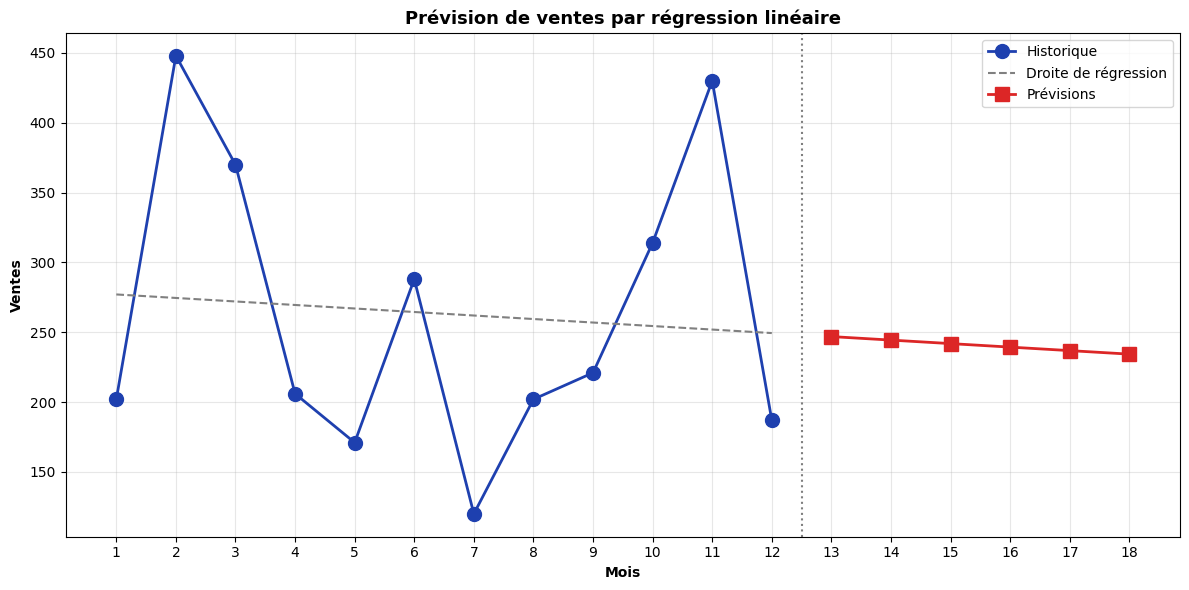

In [3]:
# ============================================================
# Exercise 3 : Prévision Time Series par régression linéaire
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Données mensuelles de ventes (12 mois)
np.random.seed(42)  # pour reproductibilité
monthly_sales_data = np.random.randint(100, 500, size=12)
print("Données mensuelles :", monthly_sales_data)

# Préparation : X = mois (1 à 12), y = ventes
months = np.arange(1, 13)

# Régression linéaire avec np.polyfit (degré 1 = droite)
# Retourne les coefficients [pente, ordonnée à l'origine]
slope, intercept = np.polyfit(months, monthly_sales_data, deg=1)
print(f"\nÉquation : y = {slope:.2f} × x + {intercept:.2f}")

# Prévision pour les 6 mois suivants (13 à 18)
future_months = np.arange(13, 19)
forecast = slope * future_months + intercept

print(f"\nPrévisions mois 13-18 :")
for m, f in zip(future_months, forecast):
    print(f"  Mois {m} : {f:.0f}")

# Visualisation
plt.figure(figsize=(12, 6))

# Données historiques
plt.plot(months, monthly_sales_data, 'o-', color='#1E40AF', linewidth=2,
         markersize=10, label='Historique')

# Droite de régression
plt.plot(months, slope * months + intercept, '--', color='gray',
         linewidth=1.5, label='Droite de régression')

# Prévisions
plt.plot(future_months, forecast, 's-', color='#DC2626', linewidth=2,
         markersize=10, label='Prévisions')

plt.axvline(12.5, color='black', linestyle=':', alpha=0.5)
plt.xlabel('Mois', fontweight='bold')
plt.ylabel('Ventes', fontweight='bold')
plt.title('Prévision de ventes par régression linéaire', fontweight='bold', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(np.arange(1, 19))
plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# Exercise 4 : Pandas — Agrégation de données
# ============================================================

import pandas as pd

# Création du DataFrame
data = {
    'Product': ['Product A', 'Product B', 'Product C', 'Product A', 'Product B'],
    'Sales': [200, 150, 300, 250, 180],
    'Month': ['January', 'February', 'March', 'April', 'May']
}
df = pd.DataFrame(data)
print("DataFrame original :")
print(df)

# ── 1) Agrégation simple : somme des ventes par produit ────
sum_by_product = df.groupby('Product')['Sales'].sum()
print("\n→ Total des ventes par produit :")
print(sum_by_product)

# ── 2) Agrégations multiples (somme, moyenne, count, max, min) ──
stats_by_product = df.groupby('Product')['Sales'].agg(['sum', 'mean', 'count', 'max', 'min'])
print("\n→ Statistiques multiples par produit :")
print(stats_by_product)

# ── 3) Agrégation avec colonnes renommées ──────────────────
named_stats = df.groupby('Product').agg(
    Total_Sales=('Sales', 'sum'),
    Avg_Sales=('Sales', 'mean'),
    Nb_Orders=('Sales', 'count')
).round(2)
print("\n→ Avec colonnes renommées :")
print(named_stats)

# ── 4) Tri du résultat ─────────────────────────────────────
top = named_stats.sort_values('Total_Sales', ascending=False)
print("\n→ Produits triés par ventes totales :")
print(top)

# ── 5) Pourcentage de contribution ─────────────────────────
named_stats['Share_%'] = (named_stats['Total_Sales'] / named_stats['Total_Sales'].sum() * 100).round(2)
print("\n→ Avec part de marché en % :")
print(named_stats)

DataFrame original :
     Product  Sales     Month
0  Product A    200   January
1  Product B    150  February
2  Product C    300     March
3  Product A    250     April
4  Product B    180       May

→ Total des ventes par produit :
Product
Product A    450
Product B    330
Product C    300
Name: Sales, dtype: int64

→ Statistiques multiples par produit :
           sum   mean  count  max  min
Product                               
Product A  450  225.0      2  250  200
Product B  330  165.0      2  180  150
Product C  300  300.0      1  300  300

→ Avec colonnes renommées :
           Total_Sales  Avg_Sales  Nb_Orders
Product                                     
Product A          450      225.0          2
Product B          330      165.0          2
Product C          300      300.0          1

→ Produits triés par ventes totales :
           Total_Sales  Avg_Sales  Nb_Orders
Product                                     
Product A          450      225.0          2
Product B        

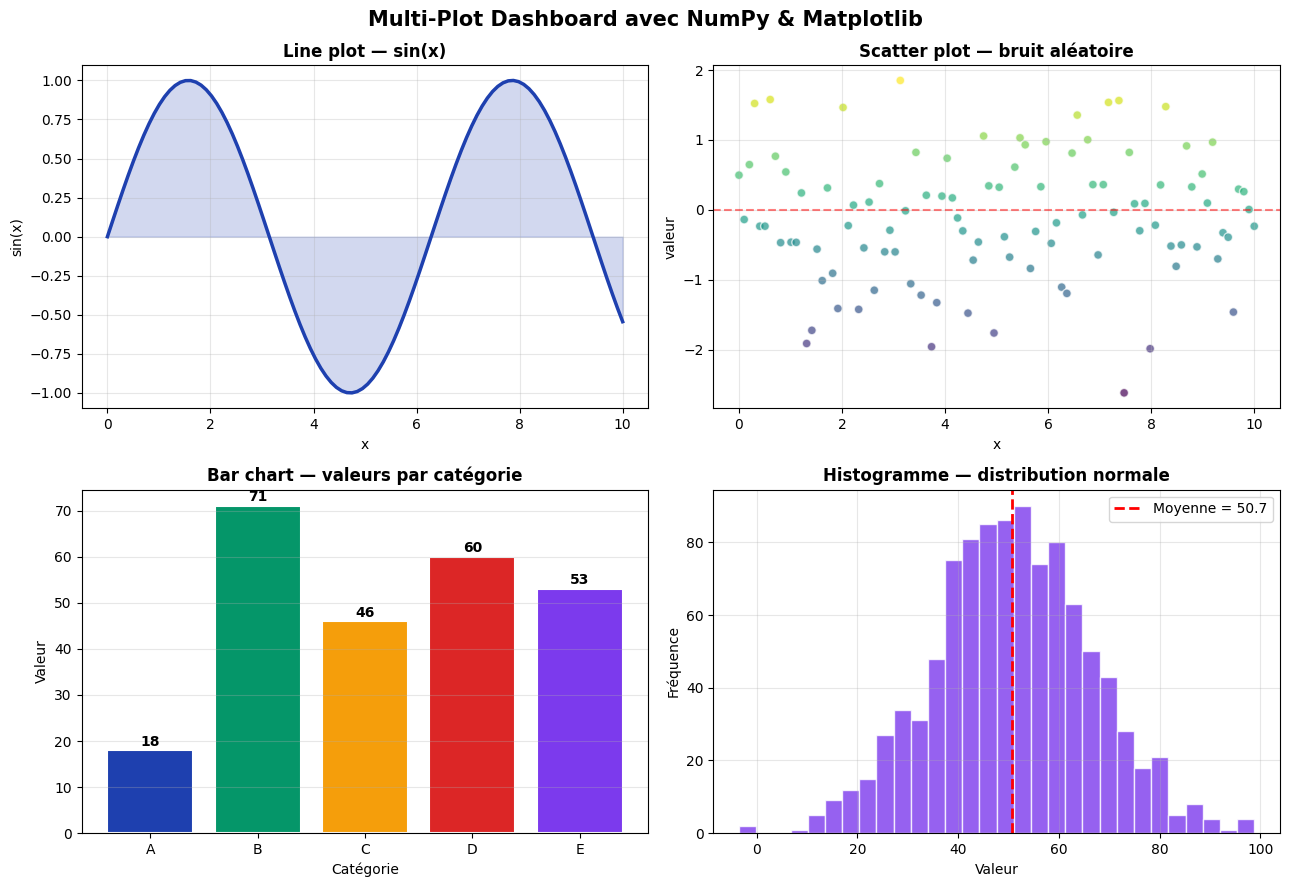

In [5]:
# ============================================================
# Exercise 5 : Visualisation multi-plot complexe
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Génération de données NumPy
np.random.seed(42)
x = np.linspace(0, 10, 100)
y_line = np.sin(x)                                # signal sinusoïdal
y_scatter = np.random.randn(100)                  # données aléatoires normales
categories = ['A', 'B', 'C', 'D', 'E']
values = np.random.randint(10, 100, size=5)       # données par catégorie
hist_data = np.random.normal(50, 15, 1000)        # distribution normale

# Création d'une grille 2x2 de sous-graphiques
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Multi-Plot Dashboard avec NumPy & Matplotlib',
             fontweight='bold', fontsize=15)

# ── Plot 1 (haut-gauche) : Line chart ──────────────────────
axes[0, 0].plot(x, y_line, color='#1E40AF', linewidth=2.5)
axes[0, 0].fill_between(x, y_line, alpha=0.2, color='#1E40AF')
axes[0, 0].set_title('Line plot — sin(x)', fontweight='bold')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('sin(x)')
axes[0, 0].grid(alpha=0.3)

# ── Plot 2 (haut-droite) : Scatter plot ────────────────────
axes[0, 1].scatter(x, y_scatter, c=y_scatter, cmap='viridis',
                   s=40, alpha=0.7, edgecolor='white')
axes[0, 1].set_title('Scatter plot — bruit aléatoire', fontweight='bold')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('valeur')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].axhline(0, color='red', linestyle='--', alpha=0.5)

# ── Plot 3 (bas-gauche) : Bar chart ────────────────────────
colors = ['#1E40AF', '#059669', '#F59E0B', '#DC2626', '#7C3AED']
bars = axes[1, 0].bar(categories, values, color=colors, edgecolor='white', linewidth=1.5)
axes[1, 0].set_title('Bar chart — valeurs par catégorie', fontweight='bold')
axes[1, 0].set_xlabel('Catégorie')
axes[1, 0].set_ylabel('Valeur')
axes[1, 0].grid(axis='y', alpha=0.3)
# Annotation des valeurs
for bar, val in zip(bars, values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, val + 1,
                    str(val), ha='center', fontweight='bold')

# ── Plot 4 (bas-droite) : Histogram ────────────────────────
axes[1, 1].hist(hist_data, bins=30, color='#7C3AED',
                edgecolor='white', alpha=0.8)
axes[1, 1].axvline(hist_data.mean(), color='red', linestyle='--',
                   linewidth=2, label=f'Moyenne = {hist_data.mean():.1f}')
axes[1, 1].set_title('Histogramme — distribution normale', fontweight='bold')
axes[1, 1].set_xlabel('Valeur')
axes[1, 1].set_ylabel('Fréquence')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()